## Ejercicio 1: Evaluación de solicitud de crédito bancario

### Ficha PEAS
- **Percepción (S):** ingreso_mensual, monto_solicitado, tiene_historial_moroso
- **Acciones (A):** aprobar, aprobar con condiciones, rechazar
- **Entorno (E):** solicitudes de crédito bancario, parcialmente observable (no se conoce con certeza el comportamiento futuro de pago del solicitante)
- **Objetivo:** aprobar créditos que el banco pueda recuperar, evitando tanto el sobre-endeudamiento del cliente como el rechazo injustificado de buenos pagadores
- **Medida de desempeño (P):** minimizar la tasa de créditos impagos y, al mismo tiempo, minimizar el número de solicitudes buenas rechazadas incorrectamente

### Justificación de las reglas
Las reglas se basan en la relación monto_solicitado / ingreso_mensual, que es un indicador
estándar de capacidad de pago en la banca: mientras más alta es esta relación, mayor es el
riesgo de que la cuota comprometa una parte excesiva del ingreso del cliente. Combinamos esta
relación con el historial moroso porque un cliente con antecedentes de impago representa un
riesgo adicional incluso si su relación monto/ingreso es baja. Por eso ambos factores altos
juntos (relación > 0.5 y moroso) llevan al rechazo directo, mientras que si solo uno de los dos
factores es riesgoso, se opta por una aprobación con condiciones (por ejemplo, una tasa de
interés mayor o un monto reducido) en lugar de un rechazo total, ya que sigue siendo un cliente
potencialmente rentable para el banco.

In [2]:
def agente_credito(ingreso_mensual, monto_solicitado, tiene_historial_moroso):
    relacion = monto_solicitado / ingreso_mensual

    if relacion > 0.5 and tiene_historial_moroso:
        return "rechazar", "relacion monto/ingreso mayor a 0.5 con historial moroso"
    elif relacion > 0.5 and not tiene_historial_moroso:
        return "aprobar con condiciones", "relacion monto/ingreso mayor a 0.5 pero sin historial moroso"
    elif relacion <= 0.5 and tiene_historial_moroso:
        return "aprobar con condiciones", "relacion menor o igual a 0.5 pero con historial moroso"
    else:
        return "aprobar", "relacion menor o igual a 0.5 y sin historial moroso"

### Simulación y pruebas

In [3]:
casos = [
    (3000, 1000, False),   # relacion 0.33, sin mora -> aprobar
    (3000, 1000, True),    # relacion 0.33, con mora -> aprobar con condiciones
    (2000, 1500, False),   # relacion 0.75, sin mora -> aprobar con condiciones
    (2000, 1500, True),    # relacion 0.75, con mora -> rechazar
    (2000, 1000, False),   # relacion 0.5 EXACTO (caso limite), sin mora -> aprobar
    (2000, 1000, True),    # relacion 0.5 EXACTO (caso limite), con mora -> aprobar con condiciones
]

for ingreso, monto, moroso in casos:
    accion, motivo = agente_credito(ingreso, monto, moroso)
    relacion = monto / ingreso
    print(f"Ingreso: S/{ingreso} | Monto: S/{monto} | Moroso: {moroso} | "
          f"Relacion: {relacion:.2f} -> {accion} ({motivo})")


Ingreso: S/3000 | Monto: S/1000 | Moroso: False | Relacion: 0.33 -> aprobar (relacion menor o igual a 0.5 y sin historial moroso)
Ingreso: S/3000 | Monto: S/1000 | Moroso: True | Relacion: 0.33 -> aprobar con condiciones (relacion menor o igual a 0.5 pero con historial moroso)
Ingreso: S/2000 | Monto: S/1500 | Moroso: False | Relacion: 0.75 -> aprobar con condiciones (relacion monto/ingreso mayor a 0.5 pero sin historial moroso)
Ingreso: S/2000 | Monto: S/1500 | Moroso: True | Relacion: 0.75 -> rechazar (relacion monto/ingreso mayor a 0.5 con historial moroso)
Ingreso: S/2000 | Monto: S/1000 | Moroso: False | Relacion: 0.50 -> aprobar (relacion menor o igual a 0.5 y sin historial moroso)
Ingreso: S/2000 | Monto: S/1000 | Moroso: True | Relacion: 0.50 -> aprobar con condiciones (relacion menor o igual a 0.5 pero con historial moroso)


### Visualización

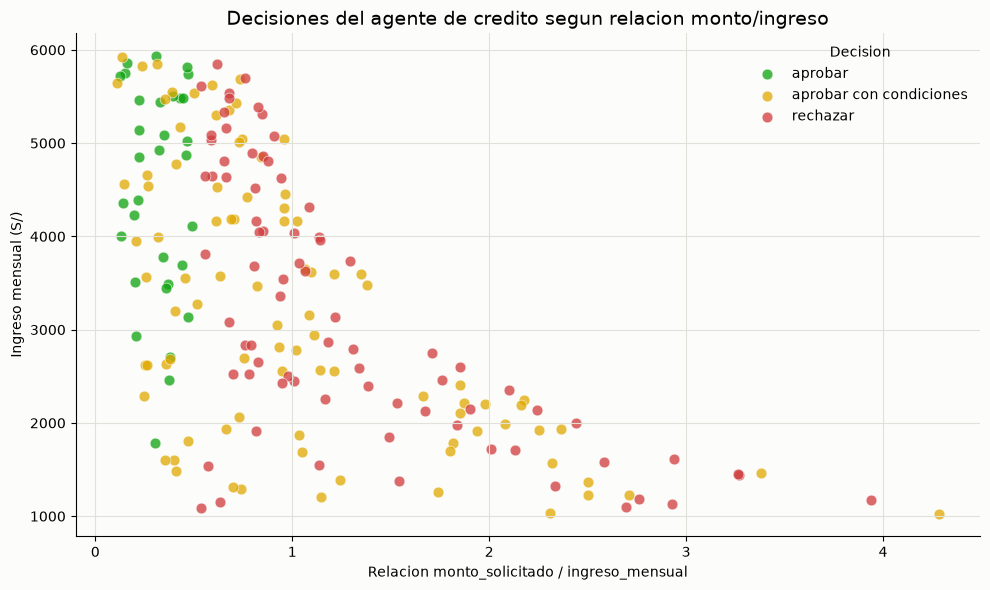

Total solicitudes: 200
  aprobar: 32
  aprobar con condiciones: 90
  rechazar: 78


In [4]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
n = 200
ingreso = np.random.uniform(1000, 6000, n)
monto = np.random.uniform(500, 5000, n)
moroso = np.random.choice([True, False], n)

decisiones = [agente_credito(i, m, h)[0] for i, m, h in zip(ingreso, monto, moroso)]
relacion = monto / ingreso

colores = {
    "aprobar": "#0ca30c",
    "aprobar con condiciones": "#e0a800",
    "rechazar": "#d03b3b",
}

fig, ax = plt.subplots(figsize=(10, 6), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")

for d in colores:
    idx = [i for i, x in enumerate(decisiones) if x == d]
    ax.scatter(relacion[idx], ingreso[idx], s=60, alpha=0.75,
               c=colores[d], edgecolors="white", linewidths=0.5, label=d)

ax.set_title("Decisiones del agente de credito segun relacion monto/ingreso", fontsize=14)
ax.set_xlabel("Relacion monto_solicitado / ingreso_mensual")
ax.set_ylabel("Ingreso mensual (S/)")
ax.legend(title="Decision", frameon=False)
ax.grid(True, color="#e1e0d9", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

print("Total solicitudes:", n)
for d in colores:
    print(f"  {d}: {decisiones.count(d)}")
